In [ ]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


for testing data
Confusion Matrix:
[[ 37   0  21   0]
 [  0  15   7   0]
 [  4   0 183   0]
 [  0   0   1   0]]
Accuracy: 0.8768656716417911
Precision: 0.879706249012645
Recall: 0.8768656716417911
F1 Score: 0.8683776409620871
for training data
Confusion Matrix:
[[110   0   0   0]
 [  0  55   0   0]
 [  0   0 457   0]
 [  0   0   0   1]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


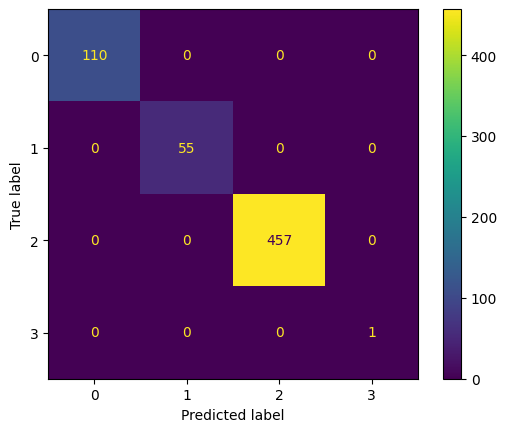

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt

a = pd.read_csv("titanic.csv")
target_column='Embarked'
X=a.drop(target_column,axis=1)
y=a[target_column]

le = LabelEncoder()
for i in X.columns:
    if X[i].dtype == 'object':
        X[i] = le.fit_transform(X[i])
if y.dtype == 'object':
    y = le.fit_transform(y)





#a = a.fillna(a.median(numeric_only=True))
#a = a.fillna(method='ffill')





X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)


model = RandomForestClassifier(

    n_estimators=600,
    max_depth=20,



)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_train_pred = model.predict(X_train)

# for testing data
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
precison = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')



print("for testing data")
print("Confusion Matrix:")
print(cm)
print("Accuracy:", acc)
print("Precision:", precison)
print("Recall:", recall)
print("F1 Score:", f1)


#for training data

cm = confusion_matrix(y_train, y_train_pred)
acc = accuracy_score(y_train, y_train_pred)
precison = precision_score(y_train, y_train_pred, average='macro')
recall = recall_score(y_train, y_train_pred, average='macro')
f1 = f1_score(y_train, y_train_pred, average='macro')



print("for training data")
print("Confusion Matrix:")
print(cm)
print("Accuracy:", acc)
print("Precision:", precison)
print("Recall:", recall)
print("F1 Score:", f1)



print(a.isnull().sum())


display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.show()










